The group "test-special-issue" is the one currently in the draft, snr=10, with FFT branch and using snapshot enforced loss

The folder "gridsearchloss3" and "gridsearchloss3-snr10" are for testing FFT branch at SNR=5 and SNR=10

In [139]:
import sys
sys.path.append('..')
import re
import yaml
import jax
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from pathlib import Path
from mpl_toolkits.axes_grid1 import ImageGrid
from matplotlib import patches as mpatches
from flowrec.utils import my_discrete_cmap, truegrey
from flowrec.utils.myplots import create_custom_colormap
from flowrec.utils.system import set_gpu
from flowrec.training_and_states import restore_trainingstate
from flowrec.physics_and_derivatives import vorticity, dissipation, get_tke, extreme_dissipation_threshold, count_extreme_events
from flowrec.postprocessing import *
from flowrec import data as data_utils
from flowrec import losses
from flowrec import signal
from functools import partial
from flowrec.utils.simulation import kolsol_forcing_term
from flowrec.signal import estimate_noise_floor
set_gpu(1,1)

In [2]:
t1 = 100
t2 = 320 # extreme events 
t3 = 2000 # extreme events
t4 = 5000
figpath = Path('./figures_for_paper/figs-extreme-events')

cmap1 = create_custom_colormap(map_name='trafficlight', type='discrete')
cmap2 = create_custom_colormap(map_name='trafficlight-pale', type='discrete')

stylefile = Path('./flowrec/utils/a4.mplstyle')
if not stylefile.exists():
    stylefile = Path('../', stylefile)
plt.style.use(stylefile)
grey = truegrey

results_dir = Path('./local_results/2dkol/extreme-events')
if not results_dir.exists():
    results_dir = Path('../', results_dir)
    if not results_dir.exists():
        raise ValueError('Results folder does not exist.')
    
if not figpath.exists():
    figpath = Path('../', figpath)
    if not figpath.exists():
        raise ValueError(f'Folder {figpath.absolute()} does not exist.')


interpolator = Interpolator().kolmogorov2d

forcing = kolsol_forcing_term(4,128,2)
partial_estimate = partial(signal.estimate_noise_floor, convergence='standard')
vestimate = jax.vmap(partial_estimate, in_axes=(1,None), out_axes=0)


In [31]:
def get_summary_onecase(d:Path, predict_only:bool=False):

    print(f"Get summary from {d}")    
    with open(Path(d,'config.yml'), 'r') as f:
        cfg = yaml.load(f, Loader=yaml.UnsafeLoader)
    
    # cfg.data_config.update({'train_test_split':(10,10,10)})



    if not Path(cfg.data_config.data_dir).exists():
        cfg.data_config.update({'data_dir':'.'+cfg.data_config.data_dir})
    datacfg = cfg.data_config
    mdlcfg = cfg.model_config
    traincfg = cfg.train_config

    data, datainfo = cfg.case.dataloader(datacfg)

    _keys_to_exclude = [
        'u_train_clean',
        'u_val_clean',
        'train_minmax',
        'val_minmax',
        'u_train',
        'u_val',
        'inn_train',
        'inn_val'
    ]
    observe_kwargs = {key: value for key, value in data.items() if key not in _keys_to_exclude}
    take_observation, insert_observation = cfg.case.observe(
        datacfg,
        example_pred_snapshot = data['u_train'][0,...],
        example_pin_snapshot = data['inn_train'][0,...],
        **observe_kwargs
    )
    observed_train, train_minmax = take_observation(data['u_train'], init=True)
    observed_val, val_minmax = take_observation(data['u_val'], init=True)
    data.update({
        'y_train':observed_train, # not normalised
        'y_val':observed_val, # not normalised
        'train_minmax':train_minmax,
        'val_minmax':val_minmax 
    })
    prep_data, make_model = cfg.case.select_model(datacfg = datacfg, mdlcfg = mdlcfg, traincfg = traincfg)
    data = prep_data(data, datainfo)
    mdl = make_model(mdlcfg)
    state = restore_trainingstate(d,'state')
    inn_train = data['inn_train']
    if datacfg.snr:
        yfull_train_clean = data['u_train_clean']
    else:
        yfull_train_clean = data['u_train']

    pred_train = []
    _t = 0
    while _t < inn_train.shape[0]:
        if (_t + 500) < inn_train.shape[0]:
            pred_train.append(
                mdl.predict(state.params, inn_train[_t:_t+500,:])
            )
        else:
            pred_train.append(
                mdl.predict(state.params, inn_train[_t:,:])
            )
        _t = _t + 500

    pred_train = np.concatenate(pred_train, axis=0)

    if cfg.data_config.normalise:
        pred_train = data_utils.unnormalise_group(pred_train, train_minmax, axis_data=-1, axis_range=0)
    observed_pred = take_observation(pred_train, init=False)

    if predict_only:
        return pred_train, (observed_train, observed_pred)#, datainfo
    else:
        sensor_locs = get_sensor_locs_2d(yfull_train_clean[:5,...], take_observation, insert_observation)

        print("    Interpolating from observations")
        u_interp, observed = interpolator(insert_observation, sensor_locs, yfull_train_clean.shape, observed_train)
    
        return (yfull_train_clean, data['u_train'], u_interp, pred_train), datainfo, observed



In [4]:
def stats_one_group(results, datainfo):
    lrel = [losses.relative_error(results['pred'][i,...], results['ref']) for i in range(3)]
    lrel_interp = [losses.relative_error(results['interp'][i,...], results['ref']) for i in range(3)]
    
    # sensor
    mask = ~np.isnan(results['observed'][:,[0],...]) # (3,1,128,128,3)
    pred_sensor = np.nan_to_num(results['pred']*mask) # (3,nt,128,128,3)
    ls = [losses.mse(pred_sensor[i,...], np.nan_to_num(results['observed'][i,...])) for i in range(3)]
    
    # physics
    lm = np.array([losses.momentum_loss(results['pred'][i,...], datainfo) for i in range(3)])
    ld = np.array([losses.divergence(results['pred'][i,...,:-1], datainfo) for i in range(3)])
    spectrum = []
    spectrum_interp = []
    eavg = []
    for i in range(3):
        _spec,_ = get_tke(results['pred'][i,...,:-1], datainfo)
        spectrum.append(_spec)
        _e = dissipation(results['pred'][i,...,:-1], datainfo)
        _eavg = np.sum(_e, axis=list(range(1,_e.ndim))) * (datainfo.dx*datainfo.dy) / (2*np.pi)**2
        eavg.append(_eavg)
        _specinterp,_ = get_tke(results['interp'][i,...,:-1], datainfo)
        spectrum_interp.append(_specinterp)
    _spec, kbins = get_tke(results['ref'][...,:-1], datainfo)
    spectrum.append(_spec)
    _e = dissipation(results['ref'][...,:-1], datainfo)
    _eavg = np.sum(_e, axis=list(range(1,_e.ndim))) * (datainfo.dx*datainfo.dy) / (2*np.pi)**2
    eavg.append(_eavg)
    

    return {'ls':np.array(ls), 'lp': lm+ld, 'ltotal':np.array(ls)+lm+ld, 'lrel':np.array(lrel), 'lrel_interp':np.array(lrel_interp), 'tke':np.array(spectrum),'tkeinterp':np.array(spectrum_interp), 'k': kbins, 'eavg': np.array(eavg)}



In [5]:
!ls ../local_results/2dkol/extreme-events/
!echo " "
!ls ../local_results/2dkol/extreme-events/change_sensors/

change_sensors	       snr10-denseinput-filter-gridsearch19
fft-snr10	       snr10-denseinput-gridsearch19
gridsearchloss3        snr10-denseinput-long-gridsearch19
gridsearchloss3-snr10  snr10-smallinput-filter-gridsearch19
nofft-snr10	       snr10-smallinput-gridsearch19
repeats


/home/ym917/.local/share/uv/python/cpython-3.11.11-linux-x86_64-gnu/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


 
snr10-sensor48-46-1358	snr10-sensor64-46-1358	snr10-sensor80-46-1358
snr10-sensor48-46-2262	snr10-sensor64-46-2262	snr10-sensor80-46-2262
snr10-sensor48-46-6312	snr10-sensor64-46-6312	snr10-sensor80-46-6312


In [6]:
test_dir_sensors = [x for x in Path(results_dir, 'change_sensors').iterdir() if x.is_dir()]
case_sensors = [80, 64, 48]
def find_case(ns, d):
    if re.search('sensor'+str(case_sensors[ns]), d.name):
        return True
    else:
        return False

def load_sensor_cases(ns, dlist):
    _dlst = [x for x in dlist if find_case(ns, x)]
    interp = []
    pred = []
    observed = []
    (ref, nref, _interp, _pred), datainfo, _observed = get_summary_onecase(_dlst[0])
    interp.append(_interp)
    pred.append(_pred)
    observed.append(_observed)
    for d in _dlst[1:]:
        (_, _, _interp, _pred), _, _observed = get_summary_onecase(d)
        interp.append(_interp)
        pred.append(_pred)
        observed.append(_observed)
    out = {
        'ref': ref,
        'nref': nref,
        'interp': np.array(interp),
        'pred': np.array(pred),
        'observed': np.array(observed),
    }
    return out, datainfo, _dlst


def find_best_case(lp, names):
    """Sort the cases based on total loss."""
    idx = np.argsort(lp)
    names_sorted = np.array(names)[idx]
    return names_sorted

def savefig(figure, save, name):
    if save:
        figure.savefig(Path(figpath, name))
    else:
        plt.pause(0.01)
        plt.show()


In [ ]:
########################### load cases ######################################
results_sensor80, datainfo, result_dir80 = load_sensor_cases(0, test_dir_sensors)
stats80 = stats_one_group(results_sensor80, datainfo)
# stats: {'ls':np.array(ls), 'lp': lm+ld, 'ltotal':np.array(ls)+lm+ld, 'lrel':np.array(lrel), 'lrel_interp':np.array(lrel_interp), 'tke':np.array(spectrum), 'k': kbins, 'eavg': np.array(eavg)}
result_dir80_sorted = find_best_case(stats80['lp'], result_dir80) # folder names sorted

In [53]:
best_seed = "-" + result_dir80_sorted[0].name.split('-')[-1]
def get_best_results_index(results_dir):
    return [i for i, d in enumerate(results_dir) if d.name.endswith(best_seed)]
idx80 = get_best_results_index(result_dir80)[0]

In [54]:
vort80 = vorticity(results_sensor80['pred'][idx80,...,:-1], datainfo)
vort80interp = vorticity(results_sensor80['interp'][idx80,...,:-1], datainfo)
vortref = vorticity(results_sensor80['ref'][...,:-1], datainfo)

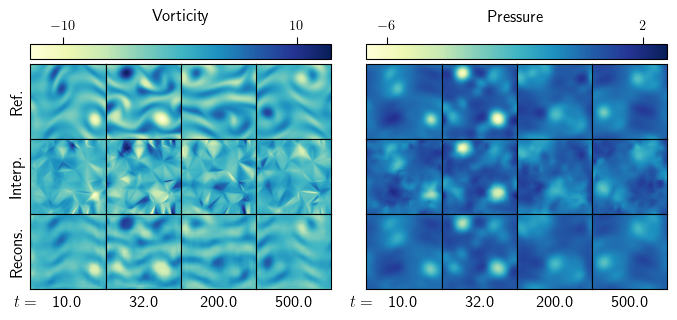

In [62]:
def plot_instantaneous_onecase(vortpred, vortinterp, results_dict, figname):
    fig6 = plt.figure(figsize=(7,3.3))
    # vorticity
    grid1 = ImageGrid(fig6, (0.07,0.07,0.43,0.85), (3,4), cbar_mode='single', axes_pad=0.0, cbar_pad=0.05, share_all=True, cbar_location='top')
    axes1 = grid1.axes_all
    cax1 = grid1.cbar_axes[0]
    grid2 = ImageGrid(fig6, (0.55,0.07,0.43,0.85), (3,4), cbar_mode='single', axes_pad=0.0, cbar_pad=0.05, share_all=True, cbar_location='top')
    axes2 = grid2.axes_all
    cax2 = grid2.cbar_axes[0]
    vmax1 = vortref.max()
    vmin1 = vortref.min()
    vmin2 = results_dict['ref'][...,-1].min()
    vmax2 = results_dict['ref'][...,-1].max()
    for i,t in enumerate([t1,t2,t3,t4]):
        # show vorticity
        im1 = axes1[i].imshow(vortref[t,...].T, vmin=vmin1, vmax=vmax1)
        axes1[i+4].imshow(vortinterp[t,...].T, vmin=vmin1, vmax=vmax1)
        axes1[i+8].imshow(vortpred[t,...].T, vmin=vmin1, vmax=vmax1)
        axes1[i].set(xticks=[], xticklabels=[], yticks=[], yticklabels=[])
        axes1[i+4].set(xticks=[], xticklabels=[], yticks=[], yticklabels=[])
        axes1[i+8].set(xticks=[], xticklabels=[], yticks=[], yticklabels=[])
        # show pressure
        im2 = axes2[i].imshow(results_dict['ref'][t,...,-1].T, vmin=vmin2, vmax=vmax2)
        axes2[i+4].imshow(results_dict['interp'][idx80,t,...,-1].T, vmin=vmin2, vmax=vmax2)
        axes2[i+8].imshow(results_dict['pred'][idx80,t,...,-1].T, vmin=vmin2, vmax=vmax2)
        axes2[i].set(xticks=[], xticklabels=[], yticks=[], yticklabels=[])
        axes2[i+4].set(xticks=[], xticklabels=[], yticks=[], yticklabels=[])
        axes2[i+8].set(xticks=[], xticklabels=[], yticks=[], yticklabels=[])
    cbar1 = cax1.colorbar(im1)
    cbar1.set_label('Vorticity', labelpad=-1)
    newticks = cbar1.get_ticks()[[1,-2]]
    cbar1.set_ticks(newticks)
    cbar1.ax.xaxis.set_label_position('top')
    cbar1.ax.xaxis.set_ticks_position('top')
    cbar2 = cax2.colorbar(im2)
    cbar2.set_label('Pressure', labelpad=-1)
    newticks = cbar2.get_ticks()[[1,-2]]
    cbar2.set_ticks(newticks)
    cbar2.ax.xaxis.set_label_position('top')
    cbar2.ax.xaxis.set_ticks_position('top')
    fig6.text(0.08,0.06,'$t=$',ha='right',va='bottom')
    fig6.text(0.56,0.06,'$t=$',ha='right',va='bottom')
    # fig6.text(0.205,0.02,f'{t1*datainfo.dt:.1f}',ha='center',va='bottom')
    # fig6.text(0.205+0.18,0.02,f'{t2*datainfo.dt:.1f}',ha='center',va='bottom')
    # fig6.text(0.205+0.18*2,0.02,f'{t3*datainfo.dt:.1f}',ha='center',va='bottom')
    # fig6.text(0.205+0.18*3,0.02,f'{t4*datainfo.dt:.1f}',ha='center',va='bottom')
    axes1[0].set_ylabel('Ref.')
    axes1[4].set_ylabel('Interp.')
    axes1[8].set_ylabel('Recons.')
    # axes2[0].set_ylabel(' ')
    # axes2[4].set_ylabel(' ')
    # axes2[8].set_ylabel(' ')
    for axes in [axes1, axes2]:
        axes[8].set_xlabel(f'{t1*datainfo.dt:.1f}')
        axes[9].set_xlabel(f'{t2*datainfo.dt:.1f}')
        axes[10].set_xlabel(f'{t3*datainfo.dt:.1f}')
        axes[11].set_xlabel(f'{t4*datainfo.dt:.1f}')

    savefig(fig6,True,figname)
    
plot_instantaneous_onecase(vort80, vort80interp, results_sensor80, 'bestcase-vort80inst')

/tmp/ipykernel_558433/2384614643.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim([stats['k'].min(),k_nyquist])


Reference flow has 8 extreme events, at [294, 477, 1358, 2003, 3089, 3671, 3753, 5706], the reconstructed flow has 14 extreme events, at [289, 469, 471, 475, 478, 1359, 2004, 2006, 3089, 3125, 3670, 3758, 3765, 5703].


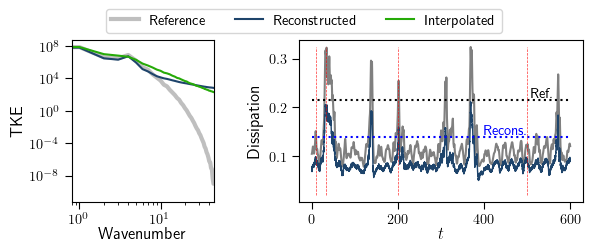

In [63]:
## tke and dissipation
def plot_tke_and_dissipation(stats, idxbest, dt, figname):
    t = dt*np.arange(len(stats['eavg'][-1,:]))
    k_nyquist = (2*np.pi / np.sqrt(2*(datainfo.dx**2))) / 2.
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(6.2,2.5),gridspec_kw={'width_ratios': [1, 2], 'wspace':0.4})
    fig.subplots_adjust(top=0.85, right=0.95)
    # tke
    ax1.loglog(stats['k'], stats['tke'][-1,:], truegrey, label='Reference', linewidth=3, alpha=0.5)
    ax1.loglog(stats['k'], stats['tke'][idxbest,:], color=my_discrete_cmap(0), label='Reconstructed')
    ax1.loglog(stats['k'], stats['tkeinterp'][idxbest,:], color=my_discrete_cmap(1), label='Interpolated')
    ax1.set_xlim([stats['k'].min(),k_nyquist])
    # ax1.vlines(32, 1e-9, 1e8, linestyle=":", color='k')
    ax1.set_ylabel('TKE')
    ax1.set_xlabel('Wavenumber', labelpad=0.0)
    # dissipation
    ax2.plot(t, stats['eavg'][-1,:], color=truegrey)
    ax2.plot(t, stats['eavg'][idxbest,:],color=my_discrete_cmap(0),linewidth=1)
    ax2.set_ylabel('Dissipation')
    ax2.set_xlabel('$t$', labelpad=0.0)
    threshold1 = np.mean(stats['eavg'][-1,:]) + 2*np.std(stats['eavg'][-1,:])
    threshold2 = np.mean(stats['eavg'][idxbest,:]) + 2*np.std(stats['eavg'][idxbest,:])
    idx1, nevents1 = count_extreme_events(stats['eavg'][-1,:], threshold1)
    idx2, nevents2 = count_extreme_events(stats['eavg'][idxbest,:], threshold2)
    print(f"Reference flow has {nevents1} extreme events, at {idx1}, the reconstructed flow has {nevents2} extreme events, at {idx2}.")
    ax2.hlines([threshold1, threshold2], 0, t.max(), color=['k','b'], linestyle=':')
    ax2.text(5100*dt, threshold1, 'Ref.', ha='left', va='bottom', fontsize='small', color='k')
    ax2.text(4000*dt, threshold2, 'Recons.', ha='left', va='bottom', fontsize='small', color='b')
    ax2.vlines(np.array([t1,t2,t3,t4])*datainfo.dt, 0.02, stats['eavg'][-1,:].max(), color='r', linewidth=0.5, linestyle='--', alpha=0.8)
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncols=3, bbox_to_anchor=(0.5,1.0), fontsize='smaller')
    fig.subplots_adjust(bottom=0.2)
    savefig(fig, True, figname)

plot_tke_and_dissipation(stats80, idx80, datainfo.dt, 'bestcase-tke-dissipation-80')

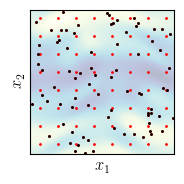

In [57]:
fig7, ax = plt.subplots(1,1,figsize=(2,2))
ax.imshow(results_sensor80['ref'][0,...,0].T, zorder=1, alpha=0.3)
ax.spy(results_sensor80['observed'][idx80,0,...,2].T, zorder=2, marker='o', color='r', origin='lower', markersize=1)
ax.spy(results_sensor80['observed'][idx80,0,...,0].T, zorder=3, marker='o', color='k', origin='lower', markersize=1)
ax.set(xticks=[], yticks=[], xlabel='$x_1$', ylabel='$x_2$')
fig7.tight_layout()
savefig(fig7, True, 'bestcase-sensor80')

In [94]:
# stats80.keys()
results_sensor80.keys()

dict_keys(['ref', 'nref', 'interp', 'pred', 'observed'])

In [98]:
sensors_inns_and_general = ~np.isnan(results_sensor80['observed'][idx80,0,...,2])
sensors_general = ~np.isnan(results_sensor80['observed'][idx80,0,...,0])
sensors_inns = sensors_inns_and_general != sensors_general
inns = results_sensor80['ref'][:,sensors_inns,-1]
num_sensors = np.count_nonzero(sensors_inns)

In [ ]:
column_names = [a.name for a in result_dir80]
column_names.append('ref')
eavg80 = pd.DataFrame(stats80['eavg'].T,columns=column_names)

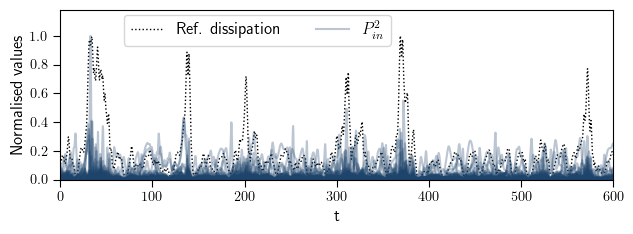

In [158]:
fig9, ax = plt.subplots(1,1,figsize=(6.5,2.5))

p = inns**2
pmax = p.max()
pmin = p.min()
time = np.arange(p.shape[0])*datainfo.dt
enorm = (eavg80.iloc[:,-1] - eavg80.min().iloc[-1]) / (eavg80.max().iloc[-1] - eavg80.min().iloc[-1])
ax.plot(time, enorm, color='k', linewidth=1, linestyle='dotted', label='Ref. dissipation')
pnorm = (p[:,0] - pmin) / (pmax - pmin)
ax.plot(time, pnorm, alpha=0.3, color=my_discrete_cmap(0), label='$P_{in}^2$')
for i in range(1,num_sensors):
    pnorm = (p[:,i] - pmin) / (pmax - pmin)
    ax.plot(time, pnorm, alpha=0.3, color=my_discrete_cmap(0))
ax.legend(ncols=2,loc='upper left', bbox_to_anchor=(0.1, 1.02))
ax.set_ylim([0,1.18])
ax.set_xlim([0,600])
ax.set(ylabel='Normalised values', xlabel='t')

fig9.tight_layout()
savefig(fig9, True, 'dissipation-compare-pin')

FFT

In [7]:
#The folder "gridsearchloss3" and "gridsearchloss3-snr10" are for testing FFT branch at SNR=5 and SNR=10
# sensor placements and noise randomseeds are the same
results_dir_fft5 = Path('../local_results/2dkol/extreme-events/gridsearchloss3')
results_dir_fft10 = Path('../local_results/2dkol/extreme-events/gridsearchloss3-snr10')

In [8]:
# !ls ../local_results/2dkol/extreme-events/gridsearchloss3

In [85]:
def get_fft_compare(results_dir:Path):
    results_dir_list = [x for x in results_dir.iterdir() if x.is_dir()]

    loss_dict = {'run':[], 'rel-l2':[], 'physics':[], 'noise-floor':[], 'fft-branch':[]}
    (ref, nref, _, _), datainfo, _ = get_summary_onecase(results_dir_list[0]) # get the slow part first
    # nref, _ = get_summary_onecase(results_dir_list[0], predict_only=True)
    nt = nref.shape[0]
    fs = 1./datainfo.dt
    loss_dict['run'].extend(['ref', 'noisyref'])
    loss_dict['rel-l2'].extend([
        np.nan, float(losses.relative_error(nref, ref))
    ])
    loss_dict['physics'].extend([
        float(losses.momentum_loss(ref, datainfo, forcing=forcing) + losses.divergence(ref[...,:-1], datainfo)),
        float(losses.momentum_loss(nref, datainfo, forcing=forcing) + losses.divergence(nref[...,:-1], datainfo)),
    ])
    estimated_power, _ = vestimate(nref.reshape((nt,-1)), fs)
    estimated_power = np.mean(estimated_power)
    loss_dict['noise-floor'].extend([
        np.nan, float(estimated_power)
    ])
    loss_dict['fft-branch'].extend([pd.NA, pd.NA])
    
    for d in results_dir_list:
        with open(Path(d,'config.yml'), 'r') as f:
            cfg = yaml.load(f, Loader=yaml.UnsafeLoader)
        fft_branch = cfg.model_config.fft_branch

        pred_train, _ = get_summary_onecase(d, predict_only=True)

        loss_dict['run'].append(d.name.split('-')[-1])
        loss_dict['rel-l2'].append(float(losses.relative_error(pred_train, ref)))
        loss_dict['physics'].append(float(
            losses.momentum_loss(pred_train, datainfo, forcing=forcing) + losses.divergence(pred_train[...,:-1], datainfo)
        ))
        estimated_power, _ = vestimate(pred_train.reshape((nt,-1)), fs)
        estimated_power = np.mean(estimated_power)
        loss_dict['noise-floor'].append(float(estimated_power))
        loss_dict['fft-branch'].append(fft_branch)

    df = pd.DataFrame(loss_dict)
    df.set_index('run', inplace=True)
    return df

In [ ]:
fftstats_snr5 = get_fft_compare(results_dir_fft5)
fftstats_snr5['snr'] = [5.0]*len(fftstats_snr5)
fftstats_snr5.loc['ref','snr'] = np.nan

In [88]:
fftstats_snr10 = get_fft_compare(results_dir_fft10)
fftstats_snr10['snr'] = [10.0]*len(fftstats_snr10)
fftstats_snr10.loc['ref','snr'] = np.nan

Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-0


/home/ym917/Codes/FlowReconstructionFromExperiment/visualisation_notebook/../train_config/train_options/dataloader.py:228: UserWarning: Unknown command line flag '_noisy'
  warnings.warn(str(e))
/home/ym917/Codes/FlowReconstructionFromExperiment/visualisation_notebook/../train_config/train_options/dataloader.py:229: UserWarning: Are you calling the dataloader from train.py?
  warnings.warn('Are you calling the dataloader from train.py?')


    Interpolating from observations
Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-0


/home/ym917/Codes/FlowReconstructionFromExperiment/visualisation_notebook/../train_config/train_options/dataloader.py:228: UserWarning: Unknown command line flag '_noisy'
  warnings.warn(str(e))
/home/ym917/Codes/FlowReconstructionFromExperiment/visualisation_notebook/../train_config/train_options/dataloader.py:229: UserWarning: Are you calling the dataloader from train.py?
  warnings.warn('Are you calling the dataloader from train.py?')


Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-8


...

Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-31
Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-3
Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-34
Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-12


/home/ym917/Codes/FlowReconstructionFromExperiment/visualisation_notebook/../train_config/train_options/dataloader.py:228: UserWarning: Unknown command line flag '_noisy'
  warnings.warn(str(e))
/home/ym917/Codes/FlowReconstructionFromExperiment/visualisation_notebook/../train_config/train_options/dataloader.py:229: UserWarning: Are you calling the dataloader from train.py?
  warnings.warn('Are you calling the dataloader from train.py?')


Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-35


/home/ym917/Codes/FlowReconstructionFromExperiment/visualisation_notebook/../train_config/train_options/dataloader.py:228: UserWarning: Unknown command line flag '_noisy'
  warnings.warn(str(e))
/home/ym917/Codes/FlowReconstructionFromExperiment/visualisation_notebook/../train_config/train_options/dataloader.py:229: UserWarning: Are you calling the dataloader from train.py?
  warnings.warn('Are you calling the dataloader from train.py?')


Get summary from ../local_results/2dkol/extreme-events/gridsearchloss3-snr10/gridsearch-23


In [89]:
fftstats = pd.concat([fftstats_snr5,fftstats_snr10]).drop_duplicates()
fftstats_grouped = fftstats.groupby(['snr','fft-branch'])

In [90]:
fftstats

,rel-l2,physics,noise-floor,fft-branch,snr
run,,,,,
ref,NaN,0.000025,NaN,<NA>,NaN
noisyref,0.562771,2237.971680,430.386169,<NA>,5.0
0,0.313622,1.136788,40.373150,False,5.0
37,0.400786,1.047610,18.831776,True,5.0
53,0.440747,1.371090,16.532265,True,5.0
...,...,...,...,...,...
3,0.231936,0.449744,9.182929,True,10.0
34,0.285176,0.530302,10.530149,False,10.0
12,0.311263,0.738321,8.147169,False,10.0


In [91]:
_means = fftstats_grouped.mean()
print(_means.loc[(5,False),'rel-l2'])
_means

0.35323186715443927


rel-l2   physics  noise-floor
snr  fft-branch                                 
5.0  False       0.353232  1.246862    36.945646
     True        0.399898  1.181171    18.899914
10.0 False       0.257369  0.513983    12.113297
     True        0.281519  0.549378     7.393942

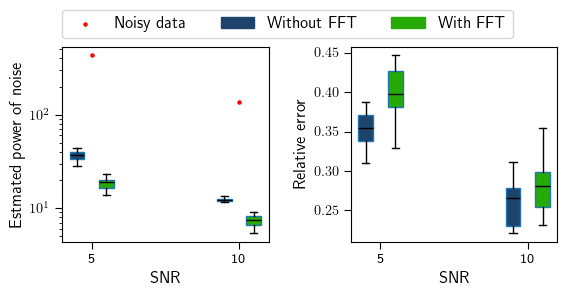

In [186]:
bp_dict = fftstats.plot.box(by=['snr','fft-branch'],column=['noise-floor','rel-l2'],figsize=(6,3), return_type='both', patch_artist = True, positions=[4.5,5.5,9.5,10.5], showfliers=False)
fig10 = bp_dict.iloc[0][0].get_figure()
for row_key, (ax,row) in bp_dict.items():
    ax.set_xlabel('SNR')
    ax.set_xticks([5,10],labels=[5,10])
    ax.set_title('')
    # print(row.keys())
    for i,box in enumerate(row['boxes']):
        box.set_facecolor(my_discrete_cmap(i%2))
    for l in ['whiskers', 'caps', 'medians', 'means']:
        for line in row[l]:
            line.set_color('black')
ax0,_ = bp_dict.iloc[0]
ax1,_ = bp_dict.iloc[1]
ax0.set_ylabel('Estmated power of noise')
ax1.set_ylabel('Relative error')
plt.subplots_adjust(wspace=0.4, top=0.85, bottom=0.2, right=0.95)
ax0.scatter(fftstats.loc['noisyref','snr'], fftstats.loc['noisyref','noise-floor'], color='r',s=5, label='Noisy data')
ax0.set_yscale('log')
# Get legend handles/labels from ax0 (for scatter)
scatter_handles, scatter_labels = ax0.get_legend_handles_labels()

# Define patch handles (for box colors)
box_handles = [
    mpatches.Patch(color=my_discrete_cmap(0), label='Without FFT'),
    mpatches.Patch(color=my_discrete_cmap(1), label='With FFT')
]
legend_handles = scatter_handles + box_handles
# Add legend to one axis (e.g., top plot)
fig10.legend(handles=legend_handles,bbox_to_anchor=(0.5,1.00), loc='upper center', ncols=3)
savefig(fig10, True, 'extreme-event-study-fft')
plt.show()